In [1]:
from tensorflow.keras.datasets import mnist

2026-10-06 20:15:38.798270: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
IOStream.flush timed out


In [2]:
(X_train, Y_class_train), (X_test, Y_class_test) = mnist.load_data()
print("학습셋 이미지 수 : %d 개" % (X_train.shape[0]))
print("테스트셋 이미지 수 : %d 개" % (X_test.shape[0]))


11490434/11490434 [==============================] - 1s 0us/step
학습셋 이미지 수 : 60000 개
테스트셋 이미지 수 : 10000 개


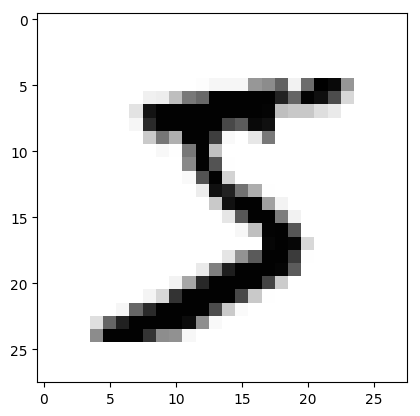

In [3]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0], cmap='Greys')
plt.show()

In [4]:
import sys
for x in X_train[0]:
    for i in x:
        sys.stdout.write('%03d '% i)	# sys.stdout.write(‘%3d' % i)
    sys.stdout.write('\n')

000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 003 018 018 018 126 136 175 026 166 255 247 127 000 000 000 000 
000 000 000 000 000 000 000 000 030 036 094 154 170 253 253 253 253 253 225 172 253 242 195 064 000 000 000 000 
000 000 000 000 000 000 000 049 238 253 253 253 253 253 253 253 253 251 093 082 082 056 039 000 000 000 000 000 
000 000 000 000 000 000 000 018 219 253 253 253 253 253 198 182 247 241 000 000 000 000 000 000 

In [6]:
X_train = X_train.reshape(X_train.shape[0], 784) # 2?차원 배열로 쫙 펼침

In [7]:
X_train = X_train.astype('float64')
X_train = X_train / 255 # 모델이 학습하게 좋도록 0~1 실수로 정규화
X_test = X_test.reshape(X_test.shape[0], 784).astype('float64') / 255

In [8]:
print("class : %d " % (Y_class_train[0]))

class : 5 


In [9]:
import tensorflow as tf
# 바이너리화 과정
Y_train = tf.keras.utils.to_categorical(Y_class_train, 10)
Y_test = tf.keras.utils.to_categorical(Y_class_test, 10)

print(Y_train[0])


[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [10]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping

# 모델 프레임 설정
model = Sequential()
model.add(Dense(512, input_dim=784, activation='relu'))
model.add(Dense(10, activation='softmax'))

# 모델 실행 환경 설정 
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

2026-10-06 20:32:10.857697: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [11]:
import os
# 모델 최적화 설정
MODEL_DIR = '../models/model1006/'
if not os.path.exists(MODEL_DIR):
    os.mkdir(MODEL_DIR)

modelpath="../models/model1006/{epoch:02d}-{val_loss:.4f}.keras"
checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss', verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=30)

# 모델의 실행
history = model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=300, batch_size=200, verbose=2, callbacks=[early_stopping_callback,checkpointer])

# 테스트 정확도 출력 
print("\n Test Accuracy: %.4f" % (model.evaluate(X_test, Y_test) [1]))


Epoch 1/300

Epoch 1: val_loss improved from inf to 0.15545, saving model to ./model1006/01-0.1555.keras
300/300 - 9s - loss: 0.3023 - accuracy: 0.9146 - val_loss: 0.1555 - val_accuracy: 0.9533 - 9s/epoch - 30ms/step
Epoch 2/300

Epoch 2: val_loss improved from 0.15545 to 0.10960, saving model to ./model1006/02-0.1096.keras
300/300 - 5s - loss: 0.1264 - accuracy: 0.9633 - val_loss: 0.1096 - val_accuracy: 0.9669 - 5s/epoch - 15ms/step
Epoch 3/300

Epoch 3: val_loss improved from 0.10960 to 0.08385, saving model to ./model1006/03-0.0839.keras
300/300 - 4s - loss: 0.0851 - accuracy: 0.9750 - val_loss: 0.0839 - val_accuracy: 0.9743 - 4s/epoch - 15ms/step
Epoch 4/300

Epoch 4: val_loss improved from 0.08385 to 0.07322, saving model to ./model1006/04-0.0732.keras
300/300 - 4s - loss: 0.0612 - accuracy: 0.9826 - val_loss: 0.0732 - val_accuracy: 0.9763 - 4s/epoch - 15ms/step
Epoch 5/300

Epoch 5: val_loss improved from 0.07322 to 0.06990, saving model to ./model1006/05-0.0699.keras
300/300 - 4

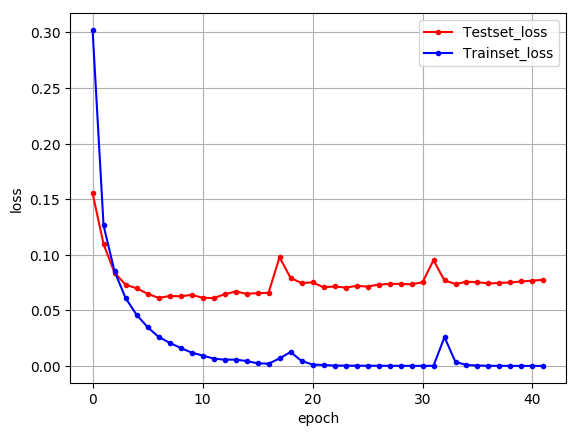

In [12]:
import numpy as np
# 테스트셋의 오차
y_vloss = history.history['val_loss']

# 학습셋의 오차
y_loss = history.history['loss']

# 그래프로 표현
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시
plt.legend(loc='upper right')
# plt.axis([0, 20, 0, 0.35])
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()
